In [1]:
import patato as pat

import numpy as np

import matplotlib.pyplot as plt
from paiskintonetools import setup_matplotlib  #  type:ignore

setup_matplotlib(dpi=300)

In [2]:
def add_scalebar(
    length: float,
    ax=None,
    color=None,
    units: str = "m",
    plot_scale=None,
    hide_label=False,
    fontproperties=None,
):
    """Add a scalebar to the desired axes with a given length.

    Args:
        distance (float): The length of the desired scalebar.
        ax (mplax.Axes, optional): The matplotlib axes to which you want to add the scalebar. Defaults to plt.gca().
        color (ColourType, optional): The colour of the scalebar. Defaults to white.
        units (str, optional): The units of the measurement. Must be supported by the Python pint library. Defaults to m (metres).
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
    import pint

    if plot_scale is None:
        plot_scale = 1

    if ax is None:
        ax = plt.gca()
    if color is None:
        color = "w"

    ureg = pint.UnitRegistry()

    q = length * ureg(units)
    bar = AnchoredSizeBar(
        ax.transData,
        length * plot_scale,
        f"{q:.0f~#P}" if not hide_label else None,
        "lower right",
        frameon=False,
        color=color,  # type: ignore
        pad=0.1,
        borderpad=0.5,
        sep=5,
        fontproperties=fontproperties,
    )
    ax.add_artist(bar)

In [3]:
import json
from pathlib import Path

settings = json.load(open("../data_paths.json", "r"))
print(settings)
data_path = (Path.cwd() / "../" / settings["main_data_path"]).resolve()
pa_example = pat.PAData.from_hdf5(data_path / "SKIN01/Scan_35.hdf5")
pa_example_bicep = pat.PAData.from_hdf5(data_path / "SKIN01/Scan_6.hdf5")

{'main_data_path': '/Volumes/Extreme SSD/Papers/PAISKINTONE/Data', 'vitiligo_data_path': '/Volumes/Extreme SSD/Papers/PAISKINTONE/Vitiligo/Data', 'melanin_ultrasound_path': '/Volumes/Extreme SSD/Papers/PAISKINTONE/US from PA/Output', 'main_data_path_default': 'Data', 'vitiligo_data_path_default': 'Vitiligo/Data', 'melanin_ultrasound_path_default': 'US from PA/Output', 'model_path': '/Volumes/Extreme SSD/Scripts/PAISKINTONE Model Based Reconstructor/forward_model.npz'}


In [4]:
print(pa_example.get_scan_name())

forearm3a


In [5]:
pa_example.set_default_recon(("Model Based", "0"))  #  type:ignore
pa_example_bicep.set_default_recon(("Model Based", "0"))  #  type:ignore

In [6]:
images = np.squeeze(pa_example.get_scan_reconstructions().raw_data)  #  type:ignore

-0.207283385613349
-0.03396671545465374
-0.039012054370795864
-0.0519691043302293
-0.05650575523559922
-0.06454512193335488
-0.07821988692557243
-0.07831069417459076
-0.07042163967217516
-0.06433817853969115
-0.06477665406749515
-0.05275653894740561
-0.057107728586007954


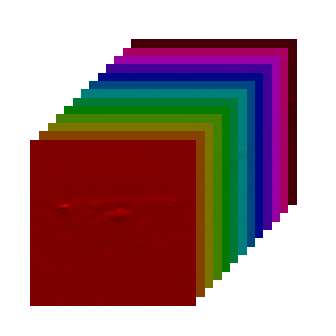

In [7]:
fig, ax = plt.subplots(figsize=(1.16, 1.16), layout="tight", facecolor="none")


colours = plt.cm.hsv  #  type:ignore
for i in range(images.shape[0] - 1, -1, -1):
    im_view = np.full(
        (
            images[i].shape[0] + 20 * images.shape[0],
            images[i].shape[1] + 20 * images.shape[0],
        ),
        np.nan,
    )
    im_view[i * 20 : i * 20 + images.shape[1], i * 20 : i * 20 + images.shape[2]] = (
        images[i]
    ).copy()
    im_norm = im_view[:, :, None]
    print(np.nanmin(im_norm))
    im_norm += 0.15
    im_norm /= np.nanmax(im_norm)
    im_norm = im_norm * colours(i / (images.shape[0] - 1))
    im_norm[..., -1] = 1
    im_norm = np.clip(im_norm, 0, 1)
    ax.imshow(im_norm, origin="lower")
ax.axis("off")
plt.tight_layout()
plt.savefig("rainbow.svg", dpi=300)
plt.show()

Legend


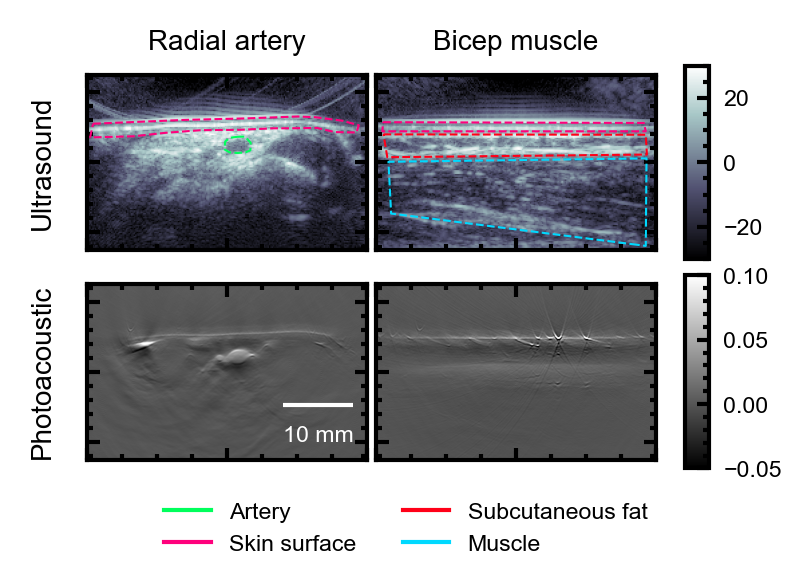

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2, figsize=(2.54, 1.76), sharex=True, sharey=True
)

ra_rois = pa_example.get_rois()
ra_rois["artery_", "0"].plot(ax=ax1, linestyle="--", linewidth=0.5, label="Artery")
ra_rois["skin_", "0"].plot(ax=ax1, linestyle="--", linewidth=0.5, label="Skin surface")
bicep_rois = pa_example_bicep.get_rois()
bicep_rois["skin_", "0"].plot(ax=ax2, linestyle="--", linewidth=0.5, label=None)
bicep_rois["fat_", "0"].plot(
    ax=ax2, linestyle="--", linewidth=0.5, label="Subcutaneous fat"
)
bicep_rois["muscle_", "0"].plot(ax=ax2, linestyle="--", linewidth=0.5, label="Muscle")


leg = fig.legend(loc="outside lower center", ncols=2, fontsize="x-small", borderpad=0.1)

print(leg)
im_us = pa_example.get_ultrasound().imshow(ax=ax1, scalebar=False, clim=(-30, 30))  #  type:ignore

pa_example_bicep.get_ultrasound().imshow(ax=ax2, scalebar=False, clim=(-30, 30))  #  type:ignore

im_pa = pa_example.get_scan_reconstructions().imshow(  #  type:ignore
    ax=ax3, scalebar=False, clim=(-0.05, 0.1), cmap="gray"
)

pa_example_bicep.get_scan_reconstructions().imshow(  #  type:ignore
    ax=ax4,
    scale_kwargs={"length_fraction": 0.5},
    scalebar=False,
    clim=(-0.05, 0.1),
    cmap="gray",
)

add_scalebar(0.01, ax3, units="m", fontproperties={"size": "x-small"})

for ax in [ax1, ax2, ax3, ax4]:
    ax.axis("on")
    ax.yaxis.set_tick_params(labelleft=False)
    ax.xaxis.set_tick_params(labelbottom=False)

ax1.set_ylim(-0.0125, 0.0125)
ax1.set_ylabel("Ultrasound", fontweight="normal", fontsize="small")
ax3.set_ylabel("Photoacoustic", fontweight="normal", fontsize="small")
ax1.set_title("Radial artery", fontweight="normal", fontsize="small")
ax2.set_title("Bicep muscle", fontweight="normal", fontsize="small")
cbar = plt.colorbar(im_us, ax=[ax1, ax2], aspect=8)  #  type:ignore
cbar.ax.tick_params(labelsize="x-small")
cbar = plt.colorbar(im_pa, ax=[ax3, ax4], aspect=8)  #  type:ignore
cbar.ax.tick_params(labelsize="x-small")
fig.get_layout_engine().set(w_pad=1 / 72, h_pad=1 / 72, hspace=0)  #  type:ignore

for line in leg.get_lines():
    line.set_linestyle("-")
    line.set_linewidth(1)

plt.savefig("annotated_images.svg", dpi=300)
plt.savefig("annotated_images.pdf", dpi=300)
plt.show()